In [1]:
from google.colab import drive 
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("/content/drive/MyDrive/MachineL/DATA/ushape.csv")

In [4]:
df

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0
...,...,...,...
94,1.699453,0.587720,1.0
95,0.218623,-0.652521,1.0
96,0.952914,-0.419766,1.0
97,-1.318500,0.423112,0.0


In [6]:
df.rename(columns={"3.159499363321345566e-02":"X","9.869877579082642072e-01":"Y","0.000000000000000000e+00":"class"},inplace=True)

In [7]:
df

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0
...,...,...,...
94,1.699453,0.587720,1.0
95,0.218623,-0.652521,1.0
96,0.952914,-0.419766,1.0
97,-1.318500,0.423112,0.0


In [8]:
import matplotlib.pyplot as plt

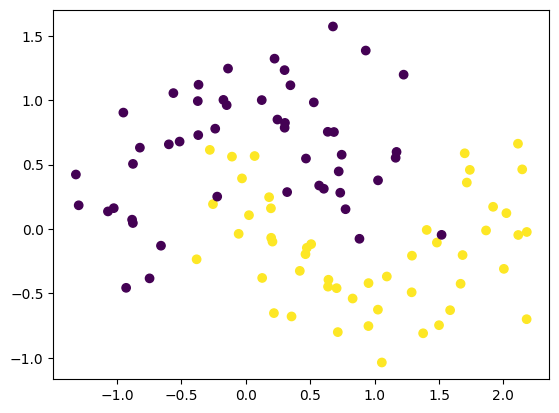

In [9]:
plt.scatter(df["X"],df["Y"],c=df["class"])

In [10]:
x=df.drop("class",axis=1)
y=df["class"]

In [12]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [13]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.get_weights()

[array([[ 1.4620848 ,  0.40795314, -1.2657913 , -0.8001061 , -2.1764324 ,
          1.7552314 , -1.2245505 ,  1.1656616 ,  0.16941914, -0.6531441 ],
        [-0.0360482 ,  0.10954873,  1.3182738 ,  1.29775   , -2.189044  ,
         -0.93755555, -1.7269487 ,  0.1213138 , -1.5498693 ,  1.0619713 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.691273  , -0.06591063, -0.2346759 ,  0.19814093,  0.69281024,
          0.46037102,  0.23746815, -0.1075152 ,  0.6604301 , -0.14820221],
        [ 0.1289148 ,  1.0033103 , -0.44207257,  0.4042168 ,  0.7049299 ,
          0.4618959 ,  0.00142711,  0.30348852,  0.20521216, -0.6062712 ],
        [ 0.8826409 ,  0.39753318,  0.33159015, -0.43295962,  0.69099736,
         -0.03148518, -0.32734612, -0.03848332,  0.14739388,  0.79604393],
        [ 0.2177314 ,  0.7705471 ,  0.17029367, -0.72367615, -0.2572608 ,
          0.20131542, -0.64976746,  0.14079157,  0.5316763 , -0.03250316],
        [ 0.77221

In [15]:
initial_weights = model.get_weights()

In [16]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [17]:
model.set_weights(initial_weights)

In [18]:
model.get_weights()

[array([[ 0.34112227, -0.192833  ,  0.3160215 ,  0.30813998,  0.9170398 ,
         -0.01699308, -0.36292228, -0.5762734 ,  0.5030405 , -0.8204175 ],
        [ 0.20870392, -0.79247564, -0.80034214, -0.582982  , -0.49487495,
          0.79082435, -0.92350894, -0.6153365 , -1.723474  , -0.600808  ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.44181365, -0.47428146, -0.5985587 ,  0.1598022 ,  0.18817209,
          0.5465813 , -0.20455101, -0.01466363,  0.669208  , -0.20649268],
        [-0.42832974,  0.78967535, -0.16122529, -0.12217011,  0.02205017,
         -0.33909345, -0.45961407, -0.02892967, -0.00251969,  0.46819958],
        [ 0.0398072 , -0.40459314,  0.19684738, -0.20296729, -0.20819989,
         -0.14456356, -0.42125764,  0.19371049,  0.259166  ,  0.14582717],
        [-0.278041  , -0.27435747,  0.0948038 ,  0.6870311 ,  0.41298598,
         -0.02103068,  0.04349465,  0.14072797, -0.3263431 ,  0.35919574],
        [ 0.07427

In [19]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
history = model.fit(x,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.5190 - loss: 0.6754 - val_accuracy: 0.5000 - val_loss: 0.6694
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5443 - loss: 0.6686 - val_accuracy: 0.5500 - val_loss: 0.6634
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5316 - loss: 0.6623 - val_accuracy: 0.5500 - val_loss: 0.6576
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6329 - loss: 0.6567 - val_accuracy: 0.7000 - val_loss: 0.6516
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7468 - loss: 0.6506 - val_accuracy: 0.7000 - val_loss: 0.6452
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7722 - loss: 0.6448 - val_accuracy: 0.7000 - val_loss: 0.6384
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7848 - loss: 0.6381 - val_accuracy: 0.7000 - val_loss: 0.6314
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7848 - loss: 0.6319 - val_accuracy: 0.7000 - val_loss

In [22]:
model.get_weights()

[array([[ 0.3196766 , -0.10739658,  0.38463217,  0.19379273,  0.9523194 ,
          0.15118201, -0.6036145 , -0.8249421 ,  0.6699198 , -0.9030945 ],
        [ 0.27508366, -0.9309982 , -0.96305114, -0.6219024 , -0.68424016,
          0.98050445, -0.799316  , -0.40980193, -1.8403486 , -0.65761524]],
       dtype=float32),
 array([-0.04918108,  0.12072509,  0.10951061, -0.01230419,  0.04472975,
         0.06054133, -0.00079216, -0.02748641,  0.20547323, -0.04294199],
       dtype=float32),
 array([[ 0.31326672, -0.4290566 , -0.4988439 ,  0.39650413,  0.24982327,
          0.5628385 , -0.07017668, -0.11614191,  0.64663166, -0.2916987 ],
        [-0.42832974,  1.0518574 ,  0.07170928, -0.19704534, -0.03483532,
         -0.18047255, -0.3867719 , -0.07151841,  0.17972551,  0.40845007],
        [ 0.06104585, -0.2625436 ,  0.33613533, -0.27823788, -0.2779827 ,
         -0.01548936, -0.60041255,  0.14043221,  0.33875898,  0.07042942],
        [-0.25208876, -0.14112692,  0.21837805,  0.61666656, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

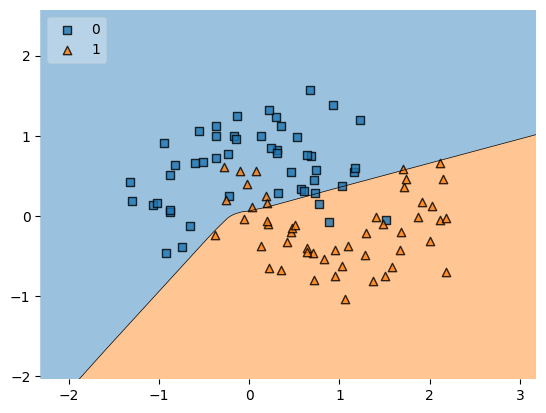

In [24]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values, y.values.astype(int), clf=model, legend=2)